# <center> PROJET DATA MANAGEMENT
## <center> BASE DE DONNEES DES VALEURS FONCIERES EN FRANCE
### <center> M2 EIF - Université Paris Dauphine - Abdoulaye GAYE
### <center> Mai 2024

# 1. IMPORTATION DES MODULES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import os

# 2. DEFINITION DU REPERTOIRE DE TRAVAIL

### Fonction permettant de définir le répertoire de travail :

In [2]:
def changeDir(newPath):
    
    try :
        os.chdir(newPath)
        print("Directory moved: newPath")
    except OSError :
        print("Directory ", newPath, "does not exist.")

    #Imprimer le répertoire du travail d'origine
    print("Base directory: ", os.getcwd())
    
    #Changer le répertoire en mettant le chemin ci-dessous
    changeDir('/Users/Huiyin/Desktop/Python/Projet')

    print("Le ficher est situé sur le chemin actuel: " + os.getcwd())

# 3. IMPORTATION DES DONNEES

### Sélection des variables qui nous permettrons d'analyser les données de la base brute des valeurs foncières :

In [3]:
col = [ "Valeur fonciere","Surface reelle bati","Surface terrain","Nombre pieces principales","Code type local",
       "Code departement","Code commune","Commune", 
       "No voie","Type de voie" ,"Voie","Code postal","Section",
       "Nature mutation" ]

## Chargement des bases de données : 

In [4]:
df21 = pd.read_csv(r"valeursfoncieres-2021.txt",sep="|",usecols=col)
df20 = pd.read_csv(r"valeursfoncieres-2020.txt",sep="|",usecols=col)
df19 = pd.read_csv(r"valeursfoncieres-2019.txt",sep="|",usecols=col)
df18 = pd.read_csv(r"valeursfoncieres-2018.txt",sep="|",usecols=col)
df17 = pd.read_csv(r"valeursfoncieres-2017.txt",sep="|",usecols=col)

/Users/jeannecocula/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (18) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [5]:
del col

### Répartition du volume de transactions entre les années pour les données brutes :

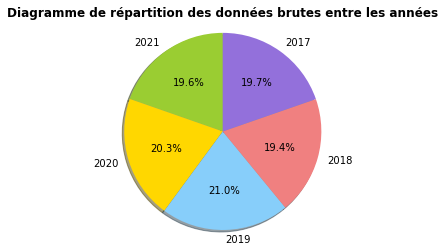

In [6]:
labels = '2021','2020','2019','2018','2017'
sizes = [len(df21),len(df20),len(df19),len(df18),len(df17)]
colors = ['yellowgreen', 'gold', 'lightskyblue', 'lightcoral', 'mediumpurple']
plt.pie(sizes, labels=labels, colors=colors,autopct='%1.1f%%', shadow=True, startangle=90)
plt.axis('equal')
plt.title("Diagramme de répartition des données brutes entre les années",fontweight='bold')
plt.show()

# 4. NETTOYAGE ET PREPROCESSING DES BASES DE DONNEES

## Routine de nettoyage et preprocessing :

In [7]:
def cleaning(donnees_brutes,annee):
    
    dfc = donnees_brutes
    
    # On renomme les variables en enlevant les espaces afin de permettre une manipulation plus aisée des données
    dfc.columns = dfc.columns.str.replace(" ","_")
    
    # On enlève les observations dans le cas où la variable "Valeur_fonciere" a une valeur NaN :
    dfc = dfc.dropna(subset=['Valeur_fonciere'])
    
    # On enlève aussi les observations dans le cas où la variable "Surface_reelle_bati" a une valeur NaN :
    dfc = dfc.dropna(subset=['Surface_reelle_bati'])
    
    # On remplace les valeurs manquantes de la variable "Surface_terrain" par 0 :
    dfc["Surface_terrain"].fillna(0,inplace=True)
    
    # On conserve seulement les observations dont la valeur de "Surface_reelle_bati" est strictement positive. 
    dfc = dfc.query('Surface_reelle_bati != 0')
    # Remarque : cela permet dans un même temps d'enlever les transactions portant sur le "Type_local" = dépendance. 
    
    # On enlève les transactions portant sur le "Type_local" = local industriel et commercial ou assimilés
    # ainsi que sur les dépendances.
    dfc = dfc.query('Code_type_local != 4 and Code_type_local != 3')
    # Remarque : seuls les maisons ('Code_type_local'=1) et les appartements ('Code_type_local'=2) sont conservés. 
   
    # Afin d'homogénéiser la nature des transactions, nous conservons seulement les observations relevant des ventes. 
    dfc = dfc.query('Nature_mutation == "Vente"')
    dfc = dfc.drop(['Nature_mutation'], axis=1)
    
    # Nous ne conservons que les observations relevant du territoire de la France métropolitaine. 
    dfc = dfc.query('Code_departement != "2A" and Code_departement != "2B"')
    dfc.Code_departement = dfc.Code_departement.astype(int)
    dfc = dfc.query('Code_departement < 99')
    
    # Nous convertissons les valeurs de la variable "Valeur_fonciere" en entier dans la perspective de manipulations futures.
    dfc.Valeur_fonciere = dfc.Valeur_fonciere.str.replace(",",".").astype(float)
    dfc.Valeur_fonciere = dfc.Valeur_fonciere.astype(int)

    # Création d'un identifiant pour chaque transaction basé sur la valeur foncière et l'adresse postale 
    # afin d'éliminer les doublons. 
    ID = dfc["Valeur_fonciere"].apply(str)  + "_" + dfc["Type_de_voie"] +'_'+ dfc["Voie"] + '_' + dfc["No_voie"].apply(str) + '_' + dfc["Code_postal"].apply(str) + '_' + dfc["Section"] 
    dfc['ID'] = ID
    dfc = dfc.drop_duplicates(subset='ID',keep=False)
    dfc = dfc.drop(['ID','Type_de_voie',"Voie","No_voie","Code_postal","Section"], axis=1)
    
    # Création de la variable "prix_m2" 
    dfc['prix_m2'] = round(dfc["Valeur_fonciere"] / dfc["Surface_reelle_bati"],3)
    
    # Conservation des transactions dont le prix au m2 est compris entre 300€ et 30,000€.
    dfc = dfc.query('prix_m2 < 30000 and prix_m2 > 300')
    
    # Conservation des transactions dont la valeur foncière ne dépasse pas 5 millions €.
    dfc = dfc.query('Valeur_fonciere < 5000000')
    
    # Création de la variable "annee" afin de pouvoir fusionner les bases de chaque année sans perdre de l'information. 
    dfc["annee"] = annee
    
    # Création de la variable "ID_com" qui nous servira pour ajouter une variable "Population_totale" pour chaque commune 
    # (voir partie 5).
    dfc['ID_com']=dfc['Code_departement'].apply(str)  + "_" + dfc["Code_commune"].apply(str)
    dfc=dfc.drop(['Code_commune'], axis=1)
    
    return dfc

## Nettoyage et preprocessing des données :

In [8]:
df21P = cleaning(df21,2021)
df20P = cleaning(df20,2020)
df19P = cleaning(df19,2019)
df18P = cleaning(df18,2018)
df17P = cleaning(df17,2017)

/Users/jeannecocula/opt/anaconda3/lib/python3.9/site-packages/pandas/core/generic.py:5516: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value
/var/folders/5p/2zm1524s6h3g0dn31wvnjpkw0000gn/T/ipykernel_31541/2985349926.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc['ID'] = ID
/var/folders/5p/2zm1524s6h3g0dn31wvnjpkw0000gn/T/ipykernel_31541/2985349926.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

In [9]:
del df21,df20,df19,df18,df17

## Fusion des bases annuelles en une seule base globale :

In [10]:
df_AllYear = pd.concat([df21P,df20P, df19P, df18P,df17P], ignore_index=True, sort=False)

### Création d'une variable "ville" pour réunir tous les arrondissements respectifs de Paris, Marseille et Lyon sous une même valeur :

In [11]:
def ville(df):
    
    dfv = df
    
    p = ["PARIS 01","PARIS 02","PARIS 03","PARIS 04","PARIS 05","PARIS 06","PARIS 07","PARIS 08","PARIS 09","PARIS 10","PARIS 11","PARIS 12","PARIS 13","PARIS 14","PARIS 15","PARIS 16","PARIS 17","PARIS 18","PARIS 19","PARIS 20"]
    l = ["LYON 1ER","LYON 2EME","LYON 3EME","LYON 4EME","LYON 5EME","LYON 6EME","LYON 7EME","LYON 8EME","LYON 9EME"]
    m = ["MARSEILLE 1ER","MARSEILLE 2EME","MARSEILLE 3EME","MARSEILLE 4EME","MARSEILLE 5EME","MARSEILLE 6EME","MARSEILLE 7EME","MARSEILLE 8EME","MARSEILLE 9EME","MARSEILLE 10EME","MARSEILLE 11EME","MARSEILLE 12EME","MARSEILLE 13EME","MARSEILLE 14EME","MARSEILLE 15EME","MARSEILLE 16EME"]
    
    dfv["ville"] = dfv["Commune"]
    for i in range(len(p)):
        dfv['ville'] = dfv['ville'].replace(p[i],"PARIS")
    for i in range(len(l)):
        dfv['ville'] = dfv['ville'].replace(l[i],"LYON")
    for i in range(len(m)):
        dfv['ville'] = dfv['ville'].replace(m[i],"MARSEILLE")
    
    return dfv

In [12]:
df21P = ville(df21P)
df20P = ville(df20P)
df19P = ville(df19P)
df18P = ville(df18P)
df17P = ville(df17P)

In [13]:
df_AllYearP=ville(df_AllYear)

## Suppression des outliers 
### Routine de suppression des outliers :
On procède à l'identification des outliers au niveau annuel et départemental, afin de conserver la diversité des caractéristiques de chaque département et de chaque année. On identifie les outliers en se basant sur la normalisation du prix au m2 pour chaque département et chaque année.

In [14]:
def stop_outliers(dataframe):
    
    param = dataframe.groupby(by = ["Code_departement","annee"]).prix_m2.describe(percentiles = None)
    param.reset_index(inplace = True)
    # On s'intéresse seulement à la moyenne et à l'écart-type du prix au m2 pour chaque département et chaque année. 
    param = param[["Code_departement","annee","mean","std"]]
    
    result = dataframe.merge(param, on = ["Code_departement","annee"], how = "left")
    # Normalisation des prix au m2
    result["prix_norm"] = abs((result["prix_m2"] - result["mean"]) / result["std"])
    result = result.query('prix_norm <= 3')
    result = result.drop(['mean','std','prix_norm'],axis=1)
    
    return result

### Mise en œuvre de la suppression des outliers :

In [15]:
df21P = stop_outliers(df21P)
df20P = stop_outliers(df20P)
df19P = stop_outliers(df19P)
df18P = stop_outliers(df18P)
df17P = stop_outliers(df17P)

In [16]:
df_AllYearP = stop_outliers(df_AllYear)

#### Suppression des villes dont on dispose de trop peu d'observations  :

In [17]:
def ville_obs(df): 

    #Recuperer le nombre d'observation par ville
    param_ville=pd.DataFrame(df.ville.value_counts())
    param_ville.rename(columns={'ville': 'Nb_obs'}, inplace=True)
    param_ville['ville']=param_ville.index
    result=df.merge(param_ville, on='ville',how='left')
    #Enlever les villes dont le nombre d'observations est inferieur a 100
    result = result.query('Nb_obs >= 100')
    result = result.drop(['Nb_obs'],axis=1)
    
    return result

In [18]:
df21P = ville_obs(df21P)
df20P = ville_obs(df20P)
df19P = ville_obs(df19P)
df18P = ville_obs(df18P)
df17P = ville_obs(df17P)

  ### Répartition du volume de transactions entre les années pour les données corrigées :

Nombre d'observations corrigées en 2021 : 408617
Nombre d'observations corrigées en 2020 : 464401
Nombre d'observations corrigées en 2019 : 496091
Nombre d'observations corrigées en 2018 : 437458
Nombre d'observations corrigées en 2017 : 444431


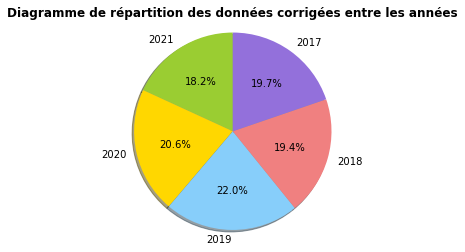

In [19]:
labels = '2021','2020','2019','2018','2017'

sizes = [len(df21P),len(df20P),len(df19P),len(df18P),len(df17P)]
print("Nombre d'observations corrigées en 2021 : "+ str(len(df21P)))
print("Nombre d'observations corrigées en 2020 : "+str(len(df20P)))
print("Nombre d'observations corrigées en 2019 : "+ str(len(df19P)))
print("Nombre d'observations corrigées en 2018 : "+str(len(df18P)))
print("Nombre d'observations corrigées en 2017 : "+ str(len(df17P)))
      
colors = ['yellowgreen', 'gold', 'lightskyblue', 'lightcoral', 'mediumpurple']
plt.pie(sizes, labels=labels, colors=colors,autopct='%1.1f%%', shadow=True, startangle=90)
plt.axis('equal')
plt.title("Diagramme de répartition des données corrigées entre les années",fontweight='bold')
plt.show()

In [20]:
df_AllYearP = ville_obs(df_AllYearP)

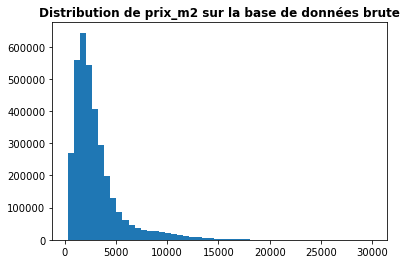

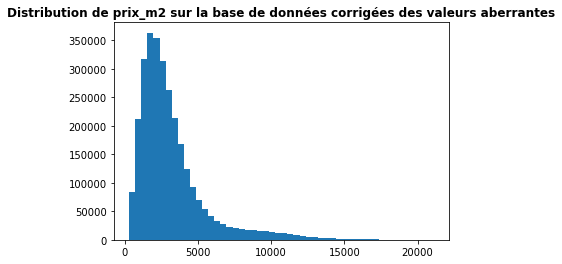

In [21]:
plt.hist(df_AllYear['prix_m2'], bins=50)
plt.title('Distribution de prix_m2 sur la base de données brute',fontweight='bold')
plt.show()
plt.hist(df_AllYearP['prix_m2'], bins=50)
plt.title('Distribution de prix_m2 sur la base de données corrigées des valeurs aberrantes',fontweight='bold')
plt.show()

In [22]:
del df21P,df20P,df19P,df18P,df17P

In [23]:
del df_AllYear

# 4. EXPLORATION STATISTIQUE DES DONNEES

   ## A- Au niveau national
   ###  Evolution du prix au m2 et de la valeur foncière au niveau national
Il est possible de choisir entre l'évolution de la variable "prix_m2" et celle de la variable "Valeur_fonciere".<br>
Ainsi, l'argument *variable* peut prendre les valeurs suivantes :
- "prix_m2"
- "Valeur_fonciere" 
***
Il est possible de s'intéresser à l'évolution selon le type de local souhaité.
<br> Ainsi, l'argument *type_local* peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"

In [24]:
def evo_nationale(variable,type_local,dataframe):
     
    if type_local == "maison" :
        df = dataframe.query('Code_type_local == 1')
        t = "des maisons "
    elif type_local == "appartement" :
        df = dataframe.query('Code_type_local == 2')
        t = "des appartements"
    elif type_local == "tout" :
        df = dataframe
        t = ""
    
    if variable == "prix_m2" :
        v = "du prix au m2 "
        p = 500
    elif variable == "Valeur_fonciere" :
        v = "de la valeur foncière "
        p = 50000
    
    # df_dist permettra d'analyser l'évolution de la distribution de la variable au niveau national.
    df_dist = df
    
    # df_France permettra d'analyser l'évolution de la variable au niveau national.
    df_France = df_dist.groupby(by="annee").describe()[variable]
    f_21 = df_France.query('annee==2021')[["25%","50%","75%"]].values[0]
    f_20 = df_France.query('annee==2020')[["25%","50%","75%"]].values[0]
    f_19 = df_France.query('annee==2019')[["25%","50%","75%"]].values[0]
    f_18 = df_France.query('annee==2018')[["25%","50%","75%"]].values[0]
    f_17 = df_France.query('annee==2017')[["25%","50%","75%"]].values[0]
    
    # Calcul du premier quartile pour chaque année.
    pf_25 = list([f_21[0],f_20[0],f_19[0],f_18[0],f_17[0]])
    # Calcul de la médiane pour chaque année.
    pf_50 = list([f_21[1],f_20[1],f_19[1],f_18[1],f_17[1]])
    # Calcul du troisième quartile pour chaque année.
    pf_75 = list([f_21[2],f_20[2],f_19[2],f_18[2],f_17[2]])
    
    # Calcul de l'évolution annuelle de la médiane.
    evo_med_f = [(pf_50[0]/pf_50[1] - 1),(pf_50[1]/pf_50[2] - 1),(pf_50[2]/pf_50[3] - 1),pf_50[3]/pf_50[4] - 1] 
    # Calcul de l'évolution totale de la médiane sur la période 2021-2017.
    total_f = (pf_50[0]/pf_50[4] - 1) * 100
    
    
    print("Evolution " +v +t +"au niveau national")
    print()
    print("2017 : médiane=",round(pf_50[4]),"€")
    print("2018 : médiane=",round(pf_50[3]),"€, évoluant de",round(evo_med_f[3] * 100,2),"%")
    print("2019 : médiane=",round(pf_50[2]),"€, évoluant de",round(evo_med_f[2] * 100,2),"%")
    print("2020 : médiane=",round(pf_50[1]),"€, évoluant de",round(evo_med_f[1] * 100,2),"%")
    print("2021 : médiane=",round(pf_50[0]),"€, évoluant de",round(evo_med_f[0] * 100,2),"%")
    print()
    print("Depuis 2017, la médiane " +v +"a evolué de", round(total_f,2),"% au total")
    
    # Graphique de l'évolution de la variable au niveau national.
    
    axis1 = [2017,2018,2019,2020,2021]
    plt.plot(axis1,pf_25[::-1],marker='.',linewidth=3, linestyle="dotted", label="prix 25%", color="gray")
    plt.plot(axis1,pf_50[::-1],marker='.',linewidth=3, linestyle="solid", label="prix médian", color="gray")
    plt.plot(axis1,pf_75[::-1],marker='.',linewidth=3, linestyle="dotted", label="prix 75%", color="gray")
    
    a=min(pf_25)-p
    b=max(pf_75)+p
    plt.title("Evolution " +v +t +"au niveau national",fontweight='bold')
    plt.ylim(a,b)
    plt.xticks(axis1)
    plt.grid(linewidth=0.5)
    plt.ylabel(variable)
    plt.grid(linewidth=0.5)
    plt.legend()
    plt.show()
    
    # Graphique de l'évolution de la distribution de la variable au niveau national.
    
    sns.kdeplot(df_dist.query('annee==2021')[variable], linewidth= 2,label="2021")
    sns.kdeplot(df_dist.query('annee==2020')[variable], linewidth= 2,label="2020")
    sns.kdeplot(df_dist.query('annee==2019')[variable], linewidth= 2,label="2019")
    sns.kdeplot(df_dist.query('annee==2018')[variable], linewidth= 2,label="2018")
    sns.kdeplot(df_dist.query('annee==2017')[variable], linewidth= 2,label="2017")
    plt.title("Evolution de la distribution " +v+ t+ "au niveau national",fontweight='bold')
    plt.xlabel(variable)
    plt.legend()
    plt.grid(linewidth=0.5)
    plt.show()
    
    return 

Evolution du prix au m2 au niveau national

2017 : médiane= 2436 €
2018 : médiane= 2463 €, évoluant de 1.11 %
2019 : médiane= 2518 €, évoluant de 2.23 %
2020 : médiane= 2600 €, évoluant de 3.28 %
2021 : médiane= 2868 €, évoluant de 10.3 %

Depuis 2017, la médiane du prix au m2 a evolué de 17.74 % au total


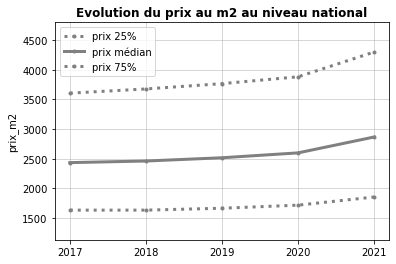

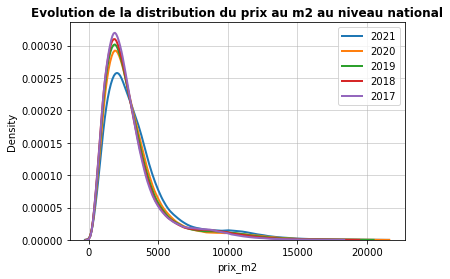

In [25]:
evo_nationale("prix_m2","tout",df_AllYearP)

## B- Au niveau régional

### (i) Appariement des observation à leur région respective 

In [26]:
List_Regions = ["AUVERGNE_RHONE_ALPES","BOURGOGNE_FRANCHE_COMTE","CENTRE_VAL_DE_LOIRE","GRAND_EST",
              "HAUTS_DE_FRANCE","NORMANDIE","NOUVELLE_AQUITAINE","OCCITANIE","PAYS_LOIRE","PACA",
              "ILE_DE_FRANCE","BRETAGNE"]

Chaque liste contient les codes des départements constituant la région correspondante :

In [27]:
List_Auvergne_Rhone_Alpes = [1,3,5,15,26,38,42,43,63,69,73,74]
List_Bourgogne_Franche_Comte = [21,25,39,58,70,71,89,90]
List_Centre_Val_de_Loire = [18,28,36,37,41,45]
List_Grand_Est = [8,10,51,52,54,55,88]
List_Hauts_de_France = [2,59,60,62,80]
List_Normandie = [14,27,50,61,76]
List_Nouvelle_Aquitaine = [16,17,19,23,24,33,40,47,64,79,86,87]
List_Occitanie = [9,11,12,30,31,32,34,46,48,65,66,81,82]
List_Pays_Loire = [44,49,63,72,85]
List_PACA = [4,5,6,13,83,84]
List_Ile_de_France = [75,77,78,91,92,93,94,95]
List_Bretagne = [22,29,35,56]

#### Création d'une nouvelle variable "Region" qui permet d'assimiler chaque observation à sa région à partir de la variable "Code_departement" :

In [28]:
def regions(code_dpt):
    
    if code_dpt in List_Auvergne_Rhone_Alpes :
        return "AUVERGNE_RHONE_ALPES"
    
    elif code_dpt in List_Bourgogne_Franche_Comte :
        return "BOURGOGNE_FRANCHE_COMTE"
    
    elif code_dpt in List_Centre_Val_de_Loire :
        return "CENTRE_VAL_DE_LOIRE"
    
    elif code_dpt in List_Grand_Est :
        return "GRAND_EST"
    
    elif code_dpt in List_Hauts_de_France :
        return "HAUTS_DE_FRANCE"
    
    elif code_dpt in List_Normandie :
        return "NORMANDIE"
    
    elif code_dpt in List_Nouvelle_Aquitaine :
        return "NOUVELLE_AQUITAINE"
    
    elif code_dpt in List_Occitanie :
        return "OCCITANIE"
    
    elif code_dpt in List_Pays_Loire :
        return "PAYS_LOIRE"
    
    elif code_dpt in List_PACA :
        return "PACA"
    
    elif code_dpt in List_Ile_de_France :
        return "ILE_DE_FRANCE"
    
    elif code_dpt in List_Bretagne :
        return "BRETAGNE"

In [29]:
df_AllYearP["Region"] = df_AllYearP["Code_departement"].apply(regions)

### (ii) Classement annuel des régions selon leur prix au m2 médian
#### Routine permettant de classer les régions selon leur prix au m2 médian, tout en calculant leur valeur foncière médiane et leur surface réelle batie médiane.
**Remarque** : il est possible de classer selon le type de local souhaité.
Ainsi, l'argument *type_local* peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"

In [30]:
def classement_regions(year,type_local,dataframe):
    
    df = dataframe.query('annee == @year')
    
    if type_local == "maison" :
        df = df.query('Code_type_local == 1')
        
    elif type_local == "appartement" :
        df = df.query('Code_type_local == 2')
        
    elif type_local == "tout" :
        df = df
        
    tri_region = df.groupby(by = ["Region"]).median().sort_values(by = "prix_m2", ascending=False)[["Valeur_fonciere",
                                                                                                    "prix_m2",
                                                                                                    "Surface_reelle_bati"]]
    
    return tri_region.head(12)

In [31]:
classement_regions(2021,"maison",df_AllYearP)

,Valeur_fonciere,prix_m2,Surface_reelle_bati
Region,,,
ILE_DE_FRANCE,347690.0,3816.6670,92.0
PACA,315960.0,3526.1290,90.0
AUVERGNE_RHONE_ALPES,269000.0,2731.8145,98.0
PAYS_LOIRE,220000.0,2474.7470,90.0
NOUVELLE_AQUITAINE,225000.0,2405.7285,92.0
BRETAGNE,228500.0,2350.5750,98.0
OCCITANIE,210000.0,2333.3330,91.0
NORMANDIE,170000.0,2032.5200,85.0
HAUTS_DE_FRANCE,160000.0,1837.5000,88.0


### (iii) Classement des régions selon l'évolution de leur prix au m2 médian
#### Routine permettant de classer les régions selon l'évolution de leur prix au m2 médian, tout en calculant l'évolution de leur valeur foncière médiane et de leur surface réelle batie médiane.
#### On s'intéresse à l'évolution totale entre 2017 et 2021, ainsi qu'à l'évolution entre 2020 et 2021.
**Remarque** : comme pour la routine précédente, il est possible de classer selon le type de local souhaité.
Ainsi, l'argument *type_local* peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"

In [32]:
def classement_var_regions(type_local,dataframe):
    
    if type_local == "maison":
        df = dataframe.query('Code_type_local == 1')
    elif type_local == "appartement":
        df = dataframe.query('Code_type_local == 2')
    elif type_local == "tout":
        df = dataframe
    
    
    List_Regions=["AUVERGNE_RHONE_ALPES","BOURGOGNE_FRANCHE_COMTE","CENTRE_VAL_DE_LOIRE","GRAND_EST",
                  "HAUTS_DE_FRANCE","NORMANDIE","NOUVELLE_AQUITAINE","OCCITANIE","PAYS_LOIRE","PACA",
                  "ILE_DE_FRANCE","BRETAGNE"]
    # Remarque : List_Regions a déjà été définie plus haut, elle est intégrée dans la routine pour plus de clareté.
    
    
    df = df.groupby(by = ["Region","annee"]).median()[["Valeur_fonciere","prix_m2","Surface_reelle_bati"]]
    
    
    # var_tot_pm2 est une liste permettant de stocker la valeur de l'évolution totale du prix au m2 médian pour chaque région.
    var_tot_pm2 = list(0 for i in range(len(List_Regions)))
    # var_20_21_pm2 est une liste permettant de stocker la valeur de l'évolution du prix au m2 médian entre 2020 et 2021 pour chaque région.
    var_20_21_pm2 = list(0 for i in range(len(List_Regions)))
    
    # var_tot_val est une liste permettant de stocker la valeur de l'évolution totale de la valeur foncière médiane pour chaque région.
    var_tot_val = list(0 for i in range(len(List_Regions)))
    # var_20_21_val est une liste permettant de stocker la valeur de l'évolution de la valeur foncière médiane entre 2020 et 2021 pour chaque région.
    var_20_21_val = list(0 for i in range(len(List_Regions)))
    
    # var_tot_sur est une liste permettant de stocker la valeur de l'évolution totale de la surface réelle batie médiane pour chaque région.
    var_tot_sur = list(0 for i in range(len(List_Regions)))
    # var_20_21_sur est une liste permettant de stocker la valeur de l'évolution totale de la surface réelle batie médiane entre 2020 et 2021 pour chaque région.
    var_20_21_sur = list(0 for i in range(len(List_Regions)))
    
    
    for i in range(len(List_Regions)):
        
        r = List_Regions[i]
        
        # Calcul de l'évolution du prix au m2 médian pour chaque région r.
        r_21_pm2 = df.query('annee==2021 and Region == @r')["prix_m2"].values[0]
        r_20_pm2 = df.query('annee==2020 and Region == @r')["prix_m2"].values[0]
        r_17_pm2 = df.query('annee==2017 and Region == @r')["prix_m2"].values[0]
        
        total_pm2 = (r_21_pm2 / r_17_pm2 - 1) * 100
        _20_21_pm2 = (r_21_pm2 / r_20_pm2 - 1) * 100
        var_tot_pm2[i] = round(total_pm2,2)
        var_20_21_pm2[i] = round(_20_21_pm2,2)
        
        # Calcul de l'évolution de la valeur foncière médiane pour chaque région r.
        r_21_val = df.query('annee==2021 and Region == @r')["Valeur_fonciere"].values[0]
        r_20_val = df.query('annee==2020 and Region == @r')["Valeur_fonciere"].values[0]
        r_17_val = df.query('annee==2017 and Region == @r')["Valeur_fonciere"].values[0]
        
        total_val = (r_21_val / r_17_val - 1) * 100
        _20_21_val = (r_21_val / r_20_val - 1) * 100
        var_tot_val[i] = round(total_val,2)
        var_20_21_val[i] = round(_20_21_val,2)
        
        # Calcul de l'évolution de la surface réelle batie médiane pour chaque région r.
        r_21_sur = df.query('annee==2021 and Region == @r')["Surface_reelle_bati"].values[0]
        r_20_sur = df.query('annee==2020 and Region == @r')["Surface_reelle_bati"].values[0]
        r_17_sur = df.query('annee==2017 and Region == @r')["Surface_reelle_bati"].values[0]
        
        total_sur = (r_21_sur / r_17_sur - 1) * 100
        _20_21_sur = (r_21_sur / r_20_sur - 1) * 100
        var_tot_sur[i] = round(total_sur,2)
        var_20_21_sur[i] = round(_20_21_sur,2)
    
    region_var = pd.DataFrame((zip(List_Regions, var_tot_pm2, var_20_21_pm2,
                                   var_tot_val, var_20_21_val, 
                                   var_tot_sur, var_20_21_sur)),
                              columns=["Region", "Variation_prix_m2_2021_2017", "Variation_prix_m2_2021_2020",
                                    "Variation_Valeur_fonciere_2021_2017", "Variation_Valeur_fonciere_2021_2020",
                                    "Variation_Surface_reelle_batie_2021_2017", "Variation_Surface_reelle_batie_2021_2020"])
    
    # Classement des données selon la variation totale du prix au m2 médian.
    region_var = region_var.sort_values(by="Variation_prix_m2_2021_2017", ascending=False)
    
    return region_var.head(12)

In [33]:
classement_var_regions("tout",df_AllYearP)

,Region,Variation_prix_m2_2021_2017,Variation_prix_m2_2021_2020,Variation_Valeur_fonciere_2021_2017,Variation_Valeur_fonciere_2021_2020,Variation_Surface_reelle_batie_2021_2017,Variation_Surface_reelle_batie_2021_2020
11,BRETAGNE,32.47,16.89,31.11,14.19,-1.30,-1.30
8,PAYS_LOIRE,28.33,11.64,26.00,10.53,0.00,0.00
6,NOUVELLE_AQUITAINE,19.93,10.63,18.84,9.05,0.00,0.00
0,AUVERGNE_RHONE_ALPES,18.94,8.73,16.13,6.27,-1.39,0.00
9,PACA,16.92,8.51,14.17,8.16,0.00,1.59
10,ILE_DE_FRANCE,13.22,6.02,16.60,5.36,0.00,0.00
4,HAUTS_DE_FRANCE,12.97,7.48,11.11,6.22,-1.23,-1.23
5,NORMANDIE,12.70,2.97,11.20,4.51,-1.41,0.00
7,OCCITANIE,12.66,5.41,12.11,5.10,0.00,0.00
3,GRAND_EST,12.31,5.29,11.64,5.86,0.00,1.30


### (iv) Evolution du prix au m2 et de la valeur foncière pour chaque région
Il est possible de choisir entre l'évolution de la variable "prix_m2" et celle de la variable "Valeur_fonciere".<br>
Ainsi, l'argument *variable* peut prendre les valeurs suivantes :
- "prix_m2"
- "Valeur_fonciere" 
***
Il est possible de s'intéresser à l'évolution selon le type de local souhaité.
<br> Ainsi, l'argument *type_local* peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"
***

Pour l'argument *region*, il faut choisir une région parmi : 
- "AUVERGNE_RHONE_ALPES"
- "BOURGOGNE_FRANCHE_COMTE"
- "CENTRE_VAL_DE_LOIRE"
- "GRAND_EST"
- "HAUTS_DE_FRANCE"
- "NORMANDIE"
- "NOUVELLE_AQUITAINE"
- "OCCITANIE"
- "PAYS_LOIRE"
- "PACA",
- "ILE_DE_FRANCE"
- "BRETAGNE"

In [34]:
def region_evo(region,variable,type_local,dataframe):
     
    if type_local == "maison" :
        df = dataframe.query('Code_type_local == 1')
        t = "des maisons "
    elif type_local == "appartement" :
        df = dataframe.query('Code_type_local == 2')
        t = "des appartements"
    elif type_local == "tout" :
        df = dataframe
        t = ""
    
    if variable == "prix_m2" :
        v = "du prix au m2 "
        p = 500
    elif variable == "Valeur_fonciere" :
        v = "de la valeur foncière "
        p = 50000
    
    # df_France permettra de faire une comparaison entre l'évolution de la variable dans la région, 
    # par rapport à son évolution au niveau national.
    df_France = df.groupby(by="annee").describe()[variable]
    f_21 = df_France.query('annee==2021')[["25%","50%","75%"]].values[0]
    f_20 = df_France.query('annee==2020')[["25%","50%","75%"]].values[0]
    f_19 = df_France.query('annee==2019')[["25%","50%","75%"]].values[0]
    f_18 = df_France.query('annee==2018')[["25%","50%","75%"]].values[0]
    f_17 = df_France.query('annee==2017')[["25%","50%","75%"]].values[0]
    
    # Calcul du premier quartile pour chaque année.
    pf_25 = list([f_21[0],f_20[0],f_19[0],f_18[0],f_17[0]])
    # Calcul de la médiane pour chaque année.
    pf_50 = list([f_21[1],f_20[1],f_19[1],f_18[1],f_17[1]])
    # Calcul du troisième quartile pour chaque année.
    pf_75 = list([f_21[2],f_20[2],f_19[2],f_18[2],f_17[2]])
    
    # Calcul de l'évolution annuelle de la médiane.
    evo_med_f = [(pf_50[0]/pf_50[1] - 1),(pf_50[1]/pf_50[2] - 1),(pf_50[2]/pf_50[3] - 1),pf_50[3]/pf_50[4] - 1] 
    # Calcul de l'évolution totale de la médiane sur la période 2021-2017.
    total_f = (pf_50[0]/pf_50[4] - 1) * 100
    
    
    df = df.query('Region == @region')
    
    # df_dist permettra d'analyser l'évolution de la distribution de la variable au niveau régional.
    df_dist = df[["annee",variable]]
    
    # df permettra d'analyser l'évolution de la variable au niveau régional.
    df = df_dist.groupby(by="annee").describe()[variable]
    r_21 = df.query('annee==2021')[["25%","50%","75%"]].values[0]
    r_20 = df.query('annee==2020')[["25%","50%","75%"]].values[0]
    r_19 = df.query('annee==2019')[["25%","50%","75%"]].values[0]
    r_18 = df.query('annee==2018')[["25%","50%","75%"]].values[0]
    r_17 = df.query('annee==2017')[["25%","50%","75%"]].values[0]
    
    p_25 = list([r_21[0],r_20[0],r_19[0],r_18[0],r_17[0]])
    p_50 = list([r_21[1],r_20[1],r_19[1],r_18[1],r_17[1]])
    p_75 = list([r_21[2],r_20[2],r_19[2],r_18[2],r_17[2]])
    evo_med = [(p_50[0]/p_50[1] - 1),(p_50[1]/p_50[2] - 1),(p_50[2]/p_50[3] - 1),p_50[3]/p_50[4] - 1] 
    total = (p_50[0]/p_50[4] - 1) * 100
    
    
    print("Evolution " +v +t +"dans la région " + region)
    print()
    print("2017 : médiane=",round(p_50[4]),"€")
    print("2018 : médiane=",round(p_50[3]),"€, évoluant de",round(evo_med[3] * 100,2),"% par rapport à 2017, contre",round(evo_med_f[3] * 100,2),"% au niveau national")
    print("2019 : médiane=",round(p_50[2]),"€, évoluant de",round(evo_med[2] * 100,2),"% par rapport à 2018, contre",round(evo_med_f[2] * 100,2),"% au niveau national")
    print("2020 : médiane=",round(p_50[1]),"€, évoluant de",round(evo_med[1] * 100,2),"% par rapport à 2019, contre",round(evo_med_f[1] * 100,2),"% au niveau national")
    print("2021 : médiane=",round(p_50[0]),"€, évoluant de",round(evo_med[0] * 100,2),"% par rapport à 2020, contre",round(evo_med_f[0] * 100,2),"% au niveau national")
    print()
    print("Depuis 2017, la médiane " +v +"a evolué de", round(total,2),"% au total, contre", round(total_f,2),"% au niveau national")
    
    # Graphique de l'évolution de la variable dans la région.
    
    axis1 = [2017,2018,2019,2020,2021]
    plt.plot(axis1,p_25[::-1],marker='.',linewidth=3, linestyle="dotted", label="prix 25%", color="navy")
    plt.plot(axis1,p_50[::-1],marker='.',linewidth=3, linestyle="solid", label="prix médian", color="navy")
    plt.plot(axis1,p_75[::-1],marker='.',linewidth=3,linestyle="dotted", label="prix 75%", color="navy")
    
    plt.plot(axis1,pf_25[::-1],linewidth=0.5,   color="navy", alpha=0)
    plt.plot(axis1,pf_50[::-1],linewidth=1, linestyle="solid",  color="gray", alpha=0.7)
    plt.plot(axis1,pf_75[::-1],linewidth=0.5,  color="navy", alpha=0)
    plt.fill_between(axis1,pf_25[::-1], pf_75[::-1], color='gray', alpha=0.2,label="IQR au niveau national")
    
    a=min(min(p_25),min(pf_25))-p
    b=max(max(p_75),max(pf_75))+p
    plt.title("Evolution " +v +t +"dans la région " + region,fontweight='bold')
    plt.ylim(a,b)
    plt.xticks(axis1)
    plt.grid(linewidth=0.5)
    plt.ylabel(variable)
    plt.grid(linewidth=0.5)
    plt.legend()
    plt.show()
    
    # Graphique de l'évolution de la distribution de la variable dans la région.
    
    sns.kdeplot(df_dist.query('annee==2021')[variable], linewidth= 2,label="2021")
    sns.kdeplot(df_dist.query('annee==2020')[variable], linewidth= 2,label="2020")
    sns.kdeplot(df_dist.query('annee==2019')[variable], linewidth= 2,label="2019")
    sns.kdeplot(df_dist.query('annee==2018')[variable], linewidth= 2,label="2018")
    sns.kdeplot(df_dist.query('annee==2017')[variable], linewidth= 2,label="2017")
    plt.title("Evolution de la distribution " +v+ t+ "dans la région  " + region,fontweight='bold')
    plt.xlabel(variable)
    plt.legend()
    plt.grid(linewidth=0.5)
    plt.show()
    
    # Boxplot sur le type d'habitation
    df_box=dataframe.query('Region == @region and annee==2021')
    sns.boxplot(x=df_box["Code_type_local"],y=df_box["Valeur_fonciere"])
    plt.title("Boxplot entre le type d'habitation et la valeur foncière dans la région de la "+ region+" en 2021",fontweight='bold')
    plt.show()
        
    return 

Evolution du prix au m2 dans la région NOUVELLE_AQUITAINE

2017 : médiane= 2231 €
2018 : médiane= 2266 €, évoluant de 1.58 % par rapport à 2017, contre 1.11 % au niveau national
2019 : médiane= 2308 €, évoluant de 1.84 % par rapport à 2018, contre 2.23 % au niveau national
2020 : médiane= 2418 €, évoluant de 4.79 % par rapport à 2019, contre 3.28 % au niveau national
2021 : médiane= 2675 €, évoluant de 10.63 % par rapport à 2020, contre 10.3 % au niveau national

Depuis 2017, la médiane du prix au m2 a evolué de 19.93 % au total, contre 17.74 % au niveau national


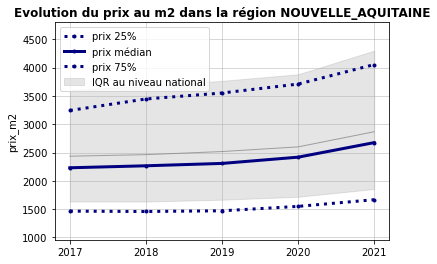

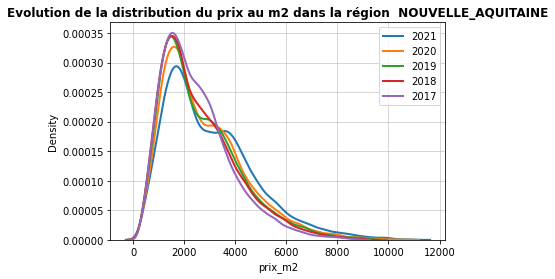

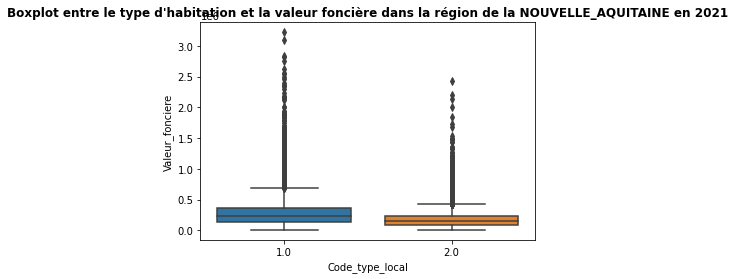

In [35]:
region_evo("NOUVELLE_AQUITAINE","prix_m2","tout",df_AllYearP)

## C- Au niveau départemental

### (i) Classement annuel des départements selon leur prix au m2 médian
#### Routine permettant de classer les départements selon leur prix au m2 médian, tout en calculant leur valeur foncière médiane et leur surface réelle batie médiane.
**Remarque** : il est possible de classer selon le type de local souhaité.
Ainsi, l'argument *type_local* peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"
***
Il est possible de choisir si on veut obtenir le haut ou le bas du classement, les prix au m2 médians étant classés par ordre croissant. Ainsi, l'argument *ordre* peut prendre les valeurs suivantes :
- "top" pour obtenir les départements ayant les prix au m2 médians les plus élevés
- "down" pour obtenir les départements ayant les prix au m2 médians les moins élevés
***
Il est aussi possible de choisir le nombre de départements que l'on veut faire apparaitre dans le classement. Ainsi, l'argument *nombre* peut prendre comme valeur tout entier compris entre 1 et 91. 

In [36]:
def classement_dpt_absolu(ordre,nombre, year,type_local,dataframe):
    
    df = dataframe.query('annee==@year')
    
    if type_local == "maison" :
        df = df.query('Code_type_local == 1')
    elif type_local == "appartement" :
        df = df.query('Code_type_local == 2')
    elif type_local == "tout" :
        df = df
    
    tri_dpt = df.groupby(by=["Code_departement"]).median().sort_values(by="prix_m2", ascending=False)[["Valeur_fonciere",
                                                                                                       "prix_m2",
                                                                                                       "Surface_reelle_bati"]]
    if ordre == "top" :
        return tri_dpt.head(nombre)
    elif ordre == "down" :
        return tri_dpt.tail(nombre)

In [37]:
classement_dpt_absolu("top",10,2021,"tout",df_AllYearP)

,Valeur_fonciere,prix_m2,Surface_reelle_bati
Code_departement,,,
75,450000.0,10869.5650,44.0
92,396000.0,7164.7060,61.0
94,285840.0,5015.3850,63.0
6,219000.0,4285.7140,56.0
93,240000.0,4030.4050,62.0
78,285000.0,4006.6670,74.0
69,255750.0,3936.1700,71.0
74,229674.5,3813.4695,64.0
33,261900.0,3777.7780,75.0


### (ii) Classement annuel des départements au sein d'une région selon leur prix au m2 médian
L'argument *type_local* peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"
***

Pour l'argument *region*, il faut choisir une région parmi : 
- "AUVERGNE_RHONE_ALPES"
- "BOURGOGNE_FRANCHE_COMTE"
- "CENTRE_VAL_DE_LOIRE"
- "GRAND_EST"
- "HAUTS_DE_FRANCE"
- "NORMANDIE"
- "NOUVELLE_AQUITAINE"
- "OCCITANIE"
- "PAYS_LOIRE"
- "PACA",
- "ILE_DE_FRANCE"
- "BRETAGNE"

In [38]:
def classement_dpt_region(region,year,type_local,dataframe):
    
    df = dataframe.query('annee == @year and Region == @region')
    
    if type_local == "maison" :
        df = df.query('Code_type_local == 1')
    elif type_local == "appartement" :
        df = df.query('Code_type_local == 2')
    elif type_local == "tout" :
        df = df
    
    l=len(df["Code_departement"].unique())
    
    tri_dpt = df.groupby(by=["Code_departement"]).median().sort_values(by="prix_m2", ascending=False)[["Valeur_fonciere",
                                                                                                       "prix_m2",
                                                                                                       "Surface_reelle_bati"]]
    
    return tri_dpt.head(l)

In [39]:
classement_dpt_region("NOUVELLE_AQUITAINE",2021,"tout",df_AllYearP)

,Valeur_fonciere,prix_m2,Surface_reelle_bati
Code_departement,,,
33,261900.0,3777.7780,75.0
64,208145.0,3443.5050,65.0
17,229000.0,3165.8335,80.0
40,190000.0,2757.6735,74.0
86,120000.0,1742.9750,80.0
87,109000.0,1612.9070,72.0
24,119000.0,1510.2040,80.0
16,120000.0,1496.1965,84.0
19,105000.0,1444.4440,75.0


### (iii) Classement des départements selon l'évolution de leur prix au m2 médian
#### Routine permettant de classer les départements selon l'évolution de leur prix au m2 médian, tout en calculant l'évolution de leur valeur foncière médiane et de leur surface réelle batie médiane.
#### On s'intéresse à l'évolution totale entre 2017 et 2021, ainsi qu'à l'évolution entre 2020 et 2021.
L'argument *type_local* peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"
***
Il est possible de choisir si on veut obtenir le haut ou le bas du classement, les variations des prix au m2 médians étant classées par ordre croissant. Ainsi, l'argument ordre peut prendre les valeurs suivantes :
- "top" pour obtenir les départements ayant les variations les plus élevées
- "down" pour obtenir les départements ayant lesvariations les moins élevées
***
Il est aussi possible de choisir le nombre de départements que l'on veut faire apparaitre dans le classement. Ainsi, l'argument nombre peut prendre comme valeur tout entier compris entre 1 et 91.

In [40]:
def classement_var_dpt_absolu(ordre,nombre,type_local, dataframe):
    
    if type_local == "maison" :
        df = dataframe.query('Code_type_local == 1')
    elif type_local == "appartement" :
        df = dataframe.query('Code_type_local == 2')
    elif type_local == "tout" :
        df = dataframe
        
    df = df.groupby(by=["Code_departement","annee"]).median()[["Valeur_fonciere","prix_m2","Surface_reelle_bati"]]
    df.reset_index(inplace=True)
    
    # List_dpt contient tous les codes de département.
    List_dpt=list(df["Code_departement"].unique())
    
    # var_tot_pm2 est une liste permettant de stocker la valeur de l'évolution totale du prix au m2 médian pour chaque département.
    var_tot_pm2=list(0 for i in range(len(List_dpt)))
    # var_20_21_pm2 est une liste permettant de stocker la valeur de l'évolution du prix au m2 médian entre 2020 et 2021 pour chaque département.
    var_20_21_pm2=list(0 for i in range(len(List_dpt)))
    
    # var_tot_val est une liste permettant de stocker la valeur de l'évolution totale de la valeur foncière médiane pour chaque département.
    var_tot_val=list(0 for i in range(len(List_dpt)))
    # var_20_21_val est une liste permettant de stocker la valeur de l'évolution de la valeur foncière médiane entre 2020 et 2021 pour chaque département.
    var_20_21_val=list(0 for i in range(len(List_dpt)))
    
    # var_tot_sur est une liste permettant de stocker la valeur de l'évolution totale de la surface réelle batie médiane pour chaque département.
    var_tot_sur=list(0 for i in range(len(List_dpt)))
    # var_20_21_sur est une liste permettant de stocker la valeur de l'évolution totale de la surface réelle batie médiane entre 2020 et 2021 pour chaque département.
    var_20_21_sur=list(0 for i in range(len(List_dpt)))
    
    for i in range(len(List_dpt)):
        
        r = List_dpt[i]
        
        # Calcul de l'évolution du prix au m2 médian pour chaque département r.
        r_21_pm2 = df.query('annee==2021 and Code_departement == @r')["prix_m2"].values[0]
        r_20_pm2 = df.query('annee==2020 and Code_departement == @r')["prix_m2"].values[0]
        r_17_pm2 = df.query('annee==2017 and Code_departement == @r')["prix_m2"].values[0]
        
        total_pm2 = (r_21_pm2/r_17_pm2 - 1) * 100
        _20_21_pm2=(r_21_pm2/r_20_pm2 - 1) * 100
        var_tot_pm2[i]=round(total_pm2,2)
        var_20_21_pm2[i]=round(_20_21_pm2,2)
        
        # Calcul de l'évolution de la valeur foncière médiane pour chaque département r.
        r_21_val = df.query('annee==2021 and Code_departement == @r')["Valeur_fonciere"].values[0]
        r_20_val = df.query('annee==2020 and Code_departement == @r')["Valeur_fonciere"].values[0]
        r_17_val = df.query('annee==2017 and Code_departement == @r')["Valeur_fonciere"].values[0]
        
        total_val = (r_21_val/r_17_val - 1) * 100
        _20_21_val=(r_21_val/r_20_val - 1) * 100
        var_tot_val[i]=round(total_val,2)
        var_20_21_val[i]=round(_20_21_val,2)
        
        # Calcul de l'évolution de la surface réelle batie médiane pour chaque département r.
        r_21_sur = df.query('annee==2021 and Code_departement == @r')["Surface_reelle_bati"].values[0]
        r_20_sur = df.query('annee==2020 and Code_departement == @r')["Surface_reelle_bati"].values[0]
        r_17_sur = df.query('annee==2017 and Code_departement == @r')["Surface_reelle_bati"].values[0]
        
        total_sur = (r_21_sur/r_17_sur - 1) * 100
        _20_21_sur=(r_21_sur/r_20_sur - 1) * 100
        var_tot_sur[i]=round(total_sur,2)
        var_20_21_sur[i]=round(_20_21_sur,2)
    
    dpt_var = pd.DataFrame((zip(List_dpt, var_tot_pm2, var_20_21_pm2,
                                var_tot_val, var_20_21_val, 
                                var_tot_sur, var_20_21_sur)),
                           columns=["Departement", "Variation_prix_m2_2021_2017", "Variation_prix_m2_2021_2020",
                                    "Variation_Valeur_fonciere_2021_2017", "Variation_Valeur_fonciere_2021_2020",
                                    "Variation_Surface_reelle_batie_2021_2017", "Variation_Surface_reelle_batie_2021_2020"])
    
    # Classement des données selon la variation totale du prix au m2 médian.
    dpt_var=dpt_var.sort_values(by="Variation_prix_m2_2021_2017", ascending=False)
    
    if ordre == "top" :
        return dpt_var.head(nombre)
    elif ordre == "down" :
        return dpt_var.tail(nombre)

In [41]:
classement_var_dpt_absolu("top",10,"tout", df_AllYearP)

,Departement,Variation_prix_m2_2021_2017,Variation_prix_m2_2021_2020,Variation_Valeur_fonciere_2021_2017,Variation_Valeur_fonciere_2021_2020,Variation_Surface_reelle_batie_2021_2017,Variation_Surface_reelle_batie_2021_2020
61,64,34.74,24.94,26.80,15.64,-2.99,-2.99
42,44,34.02,10.11,31.43,9.52,0.00,0.00
64,69,33.49,7.91,33.20,8.81,0.00,1.43
27,29,32.88,12.67,26.03,10.40,-3.80,-1.30
33,35,31.09,11.19,31.96,9.63,0.00,-1.35
16,17,29.88,14.27,30.86,14.50,0.00,0.00
54,56,28.39,10.22,26.80,13.45,0.00,0.00
47,49,27.59,11.06,26.92,10.00,0.00,-1.19
31,33,27.31,5.85,26.97,6.90,-1.32,0.00
80,85,26.23,12.11,25.00,11.74,2.63,1.30


### (iv) Classement des départements au sein d'une région selon l'évolution de leur prix au m2 médian
#### Routine permettant de classer les départements selon l'évolution de leur prix au m2 médian, tout en calculant l'évolution de leur valeur foncière médiane et de leur surface réelle batie médiane.
#### On s'intéresse à l'évolution totale entre 2017 et 2021, ainsi qu'à l'évolution entre 2020 et 2021.
L'argument *type_local* peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"
***

Pour l'argument *region*, il faut choisir une région parmi : 
- "AUVERGNE_RHONE_ALPES"
- "BOURGOGNE_FRANCHE_COMTE"
- "CENTRE_VAL_DE_LOIRE"
- "GRAND_EST"
- "HAUTS_DE_FRANCE"
- "NORMANDIE"
- "NOUVELLE_AQUITAINE"
- "OCCITANIE"
- "PAYS_LOIRE"
- "PACA",
- "ILE_DE_FRANCE"
- "BRETAGNE"

In [42]:
def classement_var_dpt_region(region,type_local,dataframe):
    
    df = dataframe.query('Region == @region')
    
    if type_local == "maison" :
        df = df.query('Code_type_local == 1')
    elif type_local == "appartement" :
        df = df.query('Code_type_local == 2')
    elif type_local == "tout" :
        df = df
    
    df = df.groupby(by=["Code_departement","annee"]).median()[["Valeur_fonciere","prix_m2","Surface_reelle_bati"]]
    df.reset_index(inplace=True)
    
    # List_dpt contient tous les codes des départements de la région choisie .
    List_dpt = list(df["Code_departement"].unique())
    
    var_tot_pm2 = list(0 for i in range(len(List_dpt)))
    var_20_21_pm2 = list(0 for i in range(len(List_dpt)))
    
    var_tot_val = list(0 for i in range(len(List_dpt)))
    var_20_21_val = list(0 for i in range(len(List_dpt)))
    
    var_tot_sur = list(0 for i in range(len(List_dpt)))
    var_20_21_sur = list(0 for i in range(len(List_dpt)))
    
    for i in range(len(List_dpt)):
        
        r = List_dpt[i]
        
        r_21_pm2 = df.query('annee==2021 and Code_departement == @r')["prix_m2"].values[0]
        r_20_pm2 = df.query('annee==2020 and Code_departement == @r')["prix_m2"].values[0]
        r_17_pm2 = df.query('annee==2017 and Code_departement == @r')["prix_m2"].values[0]
        
        total_pm2 = (r_21_pm2/r_17_pm2 - 1) * 100
        _20_21_pm2 = (r_21_pm2/r_20_pm2 - 1) * 100
        var_tot_pm2[i] = round(total_pm2,2)
        var_20_21_pm2[i] = round(_20_21_pm2,2)
        
        r_21_val = df.query('annee==2021 and Code_departement == @r')["Valeur_fonciere"].values[0]
        r_20_val = df.query('annee==2020 and Code_departement == @r')["Valeur_fonciere"].values[0]
        r_17_val = df.query('annee==2017 and Code_departement == @r')["Valeur_fonciere"].values[0]
        
        total_val = (r_21_val/r_17_val - 1) * 100
        _20_21_val = (r_21_val/r_20_val - 1) * 100
        var_tot_val[i] = round(total_val,2)
        var_20_21_val[i] = round(_20_21_val,2)
        
        r_21_sur = df.query('annee==2021 and Code_departement == @r')["Surface_reelle_bati"].values[0]
        r_20_sur = df.query('annee==2020 and Code_departement == @r')["Surface_reelle_bati"].values[0]
        r_17_sur = df.query('annee==2017 and Code_departement == @r')["Surface_reelle_bati"].values[0]
        
        total_sur = (r_21_sur/r_17_sur - 1) * 100
        _20_21_sur = (r_21_sur/r_20_sur - 1) * 100
        var_tot_sur[i] = round(total_sur,2)
        var_20_21_sur[i] = round(_20_21_sur,2)
    
    dpt_var = pd.DataFrame((zip(List_dpt, var_tot_pm2, var_20_21_pm2, 
                                var_tot_val, var_20_21_val,
                                var_tot_sur, var_20_21_sur)),
                           columns=["Departement", "Variation_prix_m2_2021_2017", "Variation_prix_m2_2021_2020",
                                    "Variation_Valeur_fonciere_2021_2017", "Variation_Valeur_fonciere_2021_2020",
                                    "Variation_Surface_reelle_batie_2021_2017", "Variation_Surface_reelle_batie_2021_2020"])
    
    dpt_var=dpt_var.sort_values(by="Variation_prix_m2_2021_2017", ascending=False)
    
    return dpt_var.head(len(List_dpt))

In [43]:
classement_var_dpt_region("NOUVELLE_AQUITAINE","tout",df_AllYearP)

,Departement,Variation_prix_m2_2021_2017,Variation_prix_m2_2021_2020,Variation_Valeur_fonciere_2021_2017,Variation_Valeur_fonciere_2021_2020,Variation_Surface_reelle_batie_2021_2017,Variation_Surface_reelle_batie_2021_2020
8,64,34.74,24.94,26.80,15.64,-2.99,-2.99
1,17,29.88,14.27,30.86,14.50,0.00,0.00
5,33,27.31,5.85,26.97,6.90,-1.32,0.00
0,16,25.49,8.70,20.00,5.68,-1.18,-1.18
11,87,24.07,10.60,21.11,13.54,-1.37,0.00
6,40,23.56,12.28,22.16,11.76,0.00,1.37
10,86,17.25,8.75,15.38,5.26,2.56,1.27
4,24,15.84,7.18,19.00,10.19,1.27,4.58
2,19,15.56,4.63,10.53,0.96,-2.60,-1.96
7,47,13.19,6.91,4.12,2.02,0.00,0.00


### (v) Evolution du prix au m2 et de la valeur foncière pour chaque département
Il est possible de choisir entre l'évolution de la variable "prix_m2" et celle de la variable "Valeur_fonciere".
Ainsi, l'argument variable peut prendre les valeurs suivantes :
- "prix_m2"
- "Valeur_fonciere"
***
Il est possible de s'intéresser à l'évolution selon le type de local souhaité. 
Ainsi, l'argument type_local peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"
***
Pour l'argument *code_dpt*, il faut choisir un entier figurant dans l'une des listes suivantes, puis saisir le nom de la région associée pour l'argument *region* :
- "AUVERGNE_RHONE_ALPES" : 1,3,5,15,26,38,42,43,63,69,73,74
- "BOURGOGNE_FRANCHE_COMTE" : 21,25,39,58,70,71,89,90
- "CENTRE_VAL_DE_LOIRE" : 18,28,36,37,41,45
- "GRAND_EST" : 8,10,51,52,54,55,88
- "HAUTS_DE_FRANCE" : 2,59,60,62,80
- "NORMANDIE" : 14,27,50,61,76
- "NOUVELLE_AQUITAINE" : 16,17,19,23,24,33,40,47,64,79,86,87
- "OCCITANIE" : 9,11,12,30,31,32,34,46,48,65,66,81,82
- "PAYS_LOIRE" : 44,49,63,72,85
- "PACA" : 4,5,6,13,83,84
- "ILE_DE_FRANCE" : 75,77,78,91,92,93,94,95
- "BRETAGNE" : 22,29,35,56

In [44]:
def dpt_evo(code_dpt,region,variable,type_local,dataframe):        
        
    df = dataframe.query('Region == @region')
    
    if type_local == "maison" :
        df = df.query('Code_type_local == 1')
        t = "des maisons "
    elif type_local == "appartement" :
        df = df.query('Code_type_local == 2')
        t = "des appartements "
    elif type_local == "tout" :
        df = df
        t = ""
    
    if variable == "prix_m2" :
        v = "du prix au m2 "
        p = 500
    elif variable == "Valeur_fonciere" :
        v = "de la valeur foncière "
        p = 50000
    
    # dr permettra de faire une comparaison entre l'évolution de la variable dans le département, 
    # par rapport à son évolution au niveau régional.
    dr=df.groupby(by="annee").describe()[variable]
    
    r_21 = dr.query('annee==2021')[["25%","50%","75%"]].values[0]
    r_20 = dr.query('annee==2020')[["25%","50%","75%"]].values[0]
    r_19 = dr.query('annee==2019')[["25%","50%","75%"]].values[0]
    r_18 = dr.query('annee==2018')[["25%","50%","75%"]].values[0]
    r_17 = dr.query('annee==2017')[["25%","50%","75%"]].values[0]
    
    # Calcul du premier quartile pour chaque année.
    p_25 = list([r_21[0],r_20[0],r_19[0],r_18[0],r_17[0]])
    # Calcul de la médiane pour chaque année.
    p_50 = list([r_21[1],r_20[1],r_19[1],r_18[1],r_17[1]])
    # Calcul du troisième quartile pour chaque année.
    p_75 = list([r_21[2],r_20[2],r_19[2],r_18[2],r_17[2]])
    
    # Calcul de l'évolution annuelle de la médiane.
    evo_med_r = [(p_50[0]/p_50[1] - 1),(p_50[1]/p_50[2] - 1),(p_50[2]/p_50[3] - 1),p_50[3]/p_50[4] - 1]
    # Calcul de l'évolution totale de la médiane sur la période 2021-2017.
    total_r = (p_50[0]/p_50[4] - 1) * 100
    
    # df_dist permettra d'analyser l'évolution de la variable au niveau départemental.
    df_dist = df.query('Code_departement == @code_dpt')[["annee",variable]]
    
    # df permettra d'analyser l'évolution de la distribution de la variable au niveau départemental.    
    df=df_dist.groupby(by="annee").describe()[variable]

    dpt_21 = df.query('annee==2021')[["25%","50%","75%"]].values[0]
    dpt_20 = df.query('annee==2020')[["25%","50%","75%"]].values[0]
    dpt_19 = df.query('annee==2019')[["25%","50%","75%"]].values[0]
    dpt_18 = df.query('annee==2018')[["25%","50%","75%"]].values[0]
    dpt_17 = df.query('annee==2017')[["25%","50%","75%"]].values[0]
    
    
    prix_25 = list([dpt_21[0],dpt_20[0],dpt_19[0],dpt_18[0],dpt_17[0]])
    prix_50 = list([dpt_21[1],dpt_20[1],dpt_19[1],dpt_18[1],dpt_17[1]])
    prix_75 = list([dpt_21[2],dpt_20[2],dpt_19[2],dpt_18[2],dpt_17[2]])
    evo_med = [(prix_50[0]/prix_50[1] - 1),(prix_50[1]/prix_50[2] - 1),(prix_50[2]/prix_50[3] - 1),prix_50[3]/prix_50[4] - 1] 
    total = (prix_50[0]/prix_50[4] - 1) * 100
    
    
    print("Evolution " + v +t + "dans le département " + str(code_dpt))
    print()
    print("2017 : médiane =",round(prix_50[4]),"€")
    print("2018 : médiane =",round(prix_50[3]),"€, évoluant de",round(evo_med[3] * 100,2),"% par rapport à 2017, contre",round(evo_med_r[3] * 100,2),"% au niveau régional")
    print("2019 : médiane =",round(prix_50[2]),"€, évoluant de",round(evo_med[2] * 100,2),"% par rapport à 2018, contre",round(evo_med_r[2] * 100,2),"% au niveau régional")
    print("2020 : médiane =",round(prix_50[1]),"€, évoluant de",round(evo_med[1] * 100,2),"% par rapport à 2019, contre",round(evo_med_r[1] * 100,2),"% au niveau régional")
    print("2021 : médiane =",round(prix_50[0]),"€, évoluant de",round(evo_med[0] * 100,2),"% par rapport à 2020, contre",round(evo_med_r[0] * 100,2),"% au niveau régional")
    print()
    print("Depuis 2017, la médiane " + v+ "a evolué de", round(total,2),"% au total, contre", round(total_r,2),"% au niveau régional")
    
    # Graphique de l'évolution de la variable dans le département.
    
    axis1 = [2017,2018,2019,2020,2021]
    plt.plot(axis1,prix_25[::-1],marker='.',linewidth=3, linestyle="dotted", label="prix 25%", color="darkgreen")
    plt.plot(axis1,prix_50[::-1],marker='.',linewidth=3, linestyle="solid", label="prix médian", color="darkgreen")
    plt.plot(axis1,prix_75[::-1],marker='.',linewidth=3,linestyle="dotted", label="prix 75%", color="darkgreen")
    
    plt.plot(axis1,p_25[::-1],linewidth=0.5,   color="navy", alpha=0)
    plt.plot(axis1,p_50[::-1],linewidth=1, linestyle="solid",  color="navy", alpha=0.7)
    plt.plot(axis1,p_75[::-1],linewidth=0.5,  color="navy", alpha=0)
    plt.fill_between(axis1,p_25[::-1], p_75[::-1], color='navy', alpha=0.2,label="IQR au niveau régional")
    
    a=min(min(prix_25),min(p_25))-p
    b=max(max(prix_75),max(p_75))+p
    plt.title("Evolution " +v +t +"dans le département " + str(code_dpt),fontweight='bold')
    plt.ylim(a,b)
    plt.xticks(axis1)
    plt.ylabel(variable)
    plt.grid(linewidth=0.5)
    plt.legend()
    plt.show()
    
    # Graphique de l'évolution de la distribution de la variable dans le département.
    
    sns.kdeplot(df_dist.query('annee==2021')[variable], linewidth= 2,label="2021")
    sns.kdeplot(df_dist.query('annee==2020')[variable], linewidth= 2,label="2020")
    sns.kdeplot(df_dist.query('annee==2019')[variable], linewidth= 2,label="2019")
    sns.kdeplot(df_dist.query('annee==2018')[variable], linewidth= 2,label="2018")
    sns.kdeplot(df_dist.query('annee==2017')[variable], linewidth= 2,label="2017")
    plt.title("Evolution de la distribution " +v+ t+ "dans le département  "  + str(code_dpt),fontweight='bold')
    plt.grid(linewidth=0.5)
    plt.xlabel(variable)
    plt.legend()
    plt.show()
    
    # Boxplot sur le type d'habitation
    df_box=dataframe.query('Code_departement == @code_dpt and annee==2021')
    sns.boxplot(x=df_box["Code_type_local"],y=df_box["Valeur_fonciere"])
    plt.title("Boxplot entre le type d'habitation et la valeur foncière dans le départemen "+ str(code_dpt)+" en 2021",fontweight='bold')
    plt.show()
        
    return 

Evolution du prix au m2 dans le département 33

2017 : médiane = 2967 €
2018 : médiane = 3274 €, évoluant de 10.33 % par rapport à 2017, contre 1.58 % au niveau régional
2019 : médiane = 3398 €, évoluant de 3.78 % par rapport à 2018, contre 1.84 % au niveau régional
2020 : médiane = 3569 €, évoluant de 5.04 % par rapport à 2019, contre 4.79 % au niveau régional
2021 : médiane = 3778 €, évoluant de 5.85 % par rapport à 2020, contre 10.63 % au niveau régional

Depuis 2017, la médiane du prix au m2 a evolué de 27.31 % au total, contre 19.93 % au niveau régional


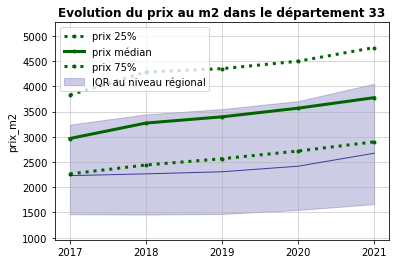

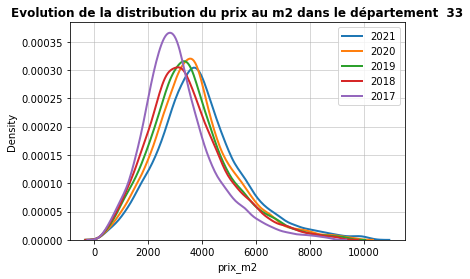

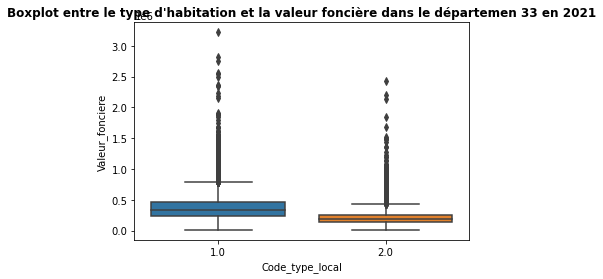

In [45]:
dpt_evo(33,"NOUVELLE_AQUITAINE","prix_m2","tout",df_AllYearP)

## D- Au niveau des villes


### (i) Classement annuel des villes selon leur prix au m2 médian
#### Routine permettant de classer les villes selon leur prix au m2 médian, tout en calculant leur valeur foncière médiane et leur surface réelle batie médiane.
**Remarque** : il est possible de classer selon le type de local souhaité.
Ainsi, l'argument *type_local* peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"
***
Il est possible de choisir si on veut obtenir le haut ou le bas du classement, les prix au m2 médians étant classés par ordre croissant. Ainsi, l'argument *ordre* peut prendre les valeurs suivantes :
- "top" pour obtenir les villes ayant les prix au m2 médians les plus élevés
- "down" pour obtenir les villes ayant les prix au m2 médians les moins élevés
***
Il est aussi possible de choisir le nombre de villes que l'on veut faire apparaitre dans le classement avec l'argument *nombre*.

In [46]:
def classement_ville_absolu(ordre, nombre,year,type_local,dataframe):
    
    df=dataframe.query('annee==@year')[["ville","Code_type_local","Valeur_fonciere","prix_m2","Surface_reelle_bati"]]
    
    if type_local=="maison":
        df=df.query('Code_type_local==1')
    elif type_local=="appartement":
        df=df.query('Code_type_local==2')
    elif type_local=="tout":
        df=df
        
    tri_commune = df.groupby(by=["ville"]).median().sort_values(by="prix_m2", ascending=False)[["Valeur_fonciere",
                                                                                                "prix_m2",
                                                                                                "Surface_reelle_bati"]]
    if ordre == "top" :
        return tri_commune.head(nombre)
    elif ordre == "down" :
        return tri_commune.tail(nombre)

In [47]:
classement_ville_absolu("top", 10,2021,"appartement",df_AllYearP)

,Valeur_fonciere,prix_m2,Surface_reelle_bati
ville,,,
NEUILLY-SUR-SEINE,818450.0,11350.6280,75.0
PARIS,450000.0,10864.0655,43.0
LEVALLOIS-PERRET,464565.0,9908.4520,49.0
SAINT-MANDE,545000.0,9486.4620,60.0
VINCENNES,438670.0,9423.0770,48.0
BOULOGNE-BILLANCOURT,475000.0,9357.1430,53.0
ISSY-LES-MOULINEAUX,416000.0,8527.7780,51.0
CHARENTON-LE-PONT,427000.0,8461.5380,55.0
LA CLUSAZ,270250.0,8312.5000,37.0


### (ii) Classement annuel des villes au sein d'une département selon leur prix au m2 médian
L'argument *type_local* peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"
***
L'argument *code_dpt* peut prendre comme valeur un entier entre 1 et 96, à l'exception du 20, 57, 67 et 68.
***
Il est possible de choisir si on veut obtenir le haut ou le bas du classement, les prix au m2 médians étant classés par ordre croissant. Ainsi, l'argument *ordre* peut prendre les valeurs suivantes :
- "top" pour obtenir les villes ayant les prix au m2 médians les plus élevés
- "down" pour obtenir les villes ayant les prix au m2 médians les moins élevés
***
Il est aussi possible de choisir le nombre de villes que l'on veut faire apparaitre dans le classement avec l'argument *nombre*.

In [48]:
def classement_ville_dpt(ordre, nombre,code_dpt,year,type_local,dataframe):
    
    df=dataframe.query('annee==@year and Code_departement==@code_dpt')[["ville","Code_type_local","Valeur_fonciere",
                                                                        "prix_m2","Surface_reelle_bati"]]
    
    if type_local=="maison":
        df=df.query('Code_type_local==1')
    elif type_local=="appartement":
        df=df.query('Code_type_local==2')
    elif type_local=="tout":
        df=df
    
    tri_commune = df.groupby(by=["ville"]).median().sort_values(by="prix_m2", ascending=False)[["Valeur_fonciere",
                                                                                                "prix_m2",
                                                                                                "Surface_reelle_bati"]]

    if ordre == "top" :
        return tri_commune.head(nombre)
    elif ordre == "down" :
        return tri_commune.tail(nombre)

In [49]:
classement_ville_dpt("top", 10,33,2021,"tout",df_AllYearP)

,Valeur_fonciere,prix_m2,Surface_reelle_bati
ville,,,
ARCACHON,332000.0,6923.0770,51.0
LEGE-CAP-FERRET,453527.5,5372.7195,85.5
ANDERNOS-LES-BAINS,420000.0,5274.1505,83.0
BORDEAUX,273720.0,4750.0000,65.0
LA TESTE-DE-BUCH,360000.0,4725.0000,81.0
ARES,330000.0,4398.8535,73.0
LE BOUSCAT,322430.0,4347.8260,76.0
GUJAN MESTRAS,369400.0,4282.6090,86.0
TALENCE,249000.0,4225.0355,67.0


### (iii) Classement des villes au sein d'un département selon l'évolution de leur prix au m2 médian
#### Routine permettant de classer les villes selon l'évolution de leur prix au m2 médian, tout en calculant l'évolution de leur valeur foncière médiane et de leur surface réelle batie médiane.
#### On s'intéresse à l'évolution totale entre 2017 et 2021, ainsi qu'à l'évolution entre 2020 et 2021.
L'argument *type_local* peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"
***
L'argument *code_dpt* peut prendre comme valeur un entier entre 1 et 96, à l'exception du 20, 57, 67 et 68.
***
Il est possible de choisir si on veut obtenir le haut ou le bas du classement, les prix au m2 médians étant classés par ordre croissant. Ainsi, l'argument *ordre* peut prendre les valeurs suivantes :
- "top" pour obtenir les villes ayant les prix au m2 médians les plus élevés
- "down" pour obtenir les villes ayant les prix au m2 médians les moins élevés
***
Il est aussi possible de choisir le nombre de villes que l'on veut faire apparaitre dans le classement avec l'argument *nombre*.

In [50]:
def classement_var_ville_dpt(ordre, nombre,code_dpt,type_local,dataframe):
    
    df=dataframe.query('Code_departement==@code_dpt')[["ville","annee","Code_type_local","Valeur_fonciere",
                                                       "prix_m2","Surface_reelle_bati"]]
    
    df=df.query('annee==2021 or annee==2020 or annee==2017')
    
    if type_local=="maison":
        df=df.query('Code_type_local==1')
    elif type_local=="appartement":
        df=df.query('Code_type_local==2')
    elif type_local=="tout":
        df=df    
    
    df = df.groupby(by=["ville","annee"]).median()[["Valeur_fonciere","prix_m2","Surface_reelle_bati"]]
    df.reset_index(inplace=True)
    
    df21=df.query('annee==2021')
    set_com_2021=set(list(df21["ville"].unique()))
    
    df20=df.query('annee==2020')
    set_com_2020=set(list(df20["ville"].unique()))
    
    df17=df.query('annee==2017')
    set_com_2017=set(list(df17["ville"].unique()))
    
    intersection_com=list(set_com_2021 & set_com_2020 & set_com_2017)
    
    var_tot_pm2=list(0 for i in range(len(intersection_com)))
    var_20_21_pm2=list(0 for i in range(len(intersection_com)))
    
    var_tot_val=list(0 for i in range(len(intersection_com)))
    var_20_21_val=list(0 for i in range(len(intersection_com)))
    
    var_tot_sur=list(0 for i in range(len(intersection_com)))
    var_20_21_sur=list(0 for i in range(len(intersection_com)))
    
    for i in range(len(intersection_com)):
        
        r=intersection_com[i]
        
        r_21_pm2 = df.query('annee==2021 and ville == @r')["prix_m2"].values[0]
        r_20_pm2 = df.query('annee==2020 and ville == @r')["prix_m2"].values[0]
        r_17_pm2 = df.query('annee==2017 and ville == @r')["prix_m2"].values[0]
        
        total_pm2 = (r_21_pm2/r_17_pm2 - 1) * 100
        _20_21_pm2=(r_21_pm2/r_20_pm2 - 1) * 100
        var_tot_pm2[i]=round(total_pm2,2)
        var_20_21_pm2[i]=round(_20_21_pm2,2)
        
        r_21_val = df.query('annee==2021 and ville == @r')["Valeur_fonciere"].values[0]
        r_20_val = df.query('annee==2020 and ville == @r')["Valeur_fonciere"].values[0]
        r_17_val = df.query('annee==2017 and ville == @r')["Valeur_fonciere"].values[0]
        
        total_val = (r_21_val/r_17_val - 1) * 100
        _20_21_val=(r_21_val/r_20_val - 1) * 100
        var_tot_val[i]=round(total_val,2)
        var_20_21_val[i]=round(_20_21_val,2)
        
        r_21_sur = df.query('annee==2021 and ville == @r')["Surface_reelle_bati"].values[0]
        r_20_sur = df.query('annee==2020 and ville == @r')["Surface_reelle_bati"].values[0]
        r_17_sur = df.query('annee==2017 and ville == @r')["Surface_reelle_bati"].values[0]
        
        total_sur = (r_21_sur/r_17_sur - 1) * 100
        _20_21_sur=(r_21_sur/r_20_sur - 1) * 100
        var_tot_sur[i]=round(total_sur,2)
        var_20_21_sur[i]=round(_20_21_sur,2)
    
    com_var = pd.DataFrame((zip(intersection_com, var_tot_pm2, var_20_21_pm2,
                                var_tot_val, var_20_21_val, 
                                var_tot_sur, var_20_21_sur)),
                           columns=["Ville", "Variation_prix_m2_2021_2017", "Variation_prix_m2_2021_2020",
                                    "Variation_Valeur_fonciere_2021_2017", "Variation_Valeur_fonciere_2021_2020",
                                    "Variation_Surface_reelle_batie_2021_2017", "Variation_Surface_reelle_batie_2021_2020"])
    
    com_var = com_var.sort_values(by="Variation_prix_m2_2021_2017", ascending=False)
    
    if ordre == "top" :
        return com_var.head(nombre)
    elif ordre == "down" :
        return com_var.tail(nombre)

In [51]:
classement_var_ville_dpt("top", 15,33,"tout",df_AllYearP)

,Ville,Variation_prix_m2_2021_2017,Variation_prix_m2_2021_2020,Variation_Valeur_fonciere_2021_2017,Variation_Valeur_fonciere_2021_2020,Variation_Surface_reelle_batie_2021_2017,Variation_Surface_reelle_batie_2021_2020
68,BEAUTIRAN,67.41,27.07,49.08,12.51,-1.56,5.00
42,VENDAYS-MONTALIVET,56.11,20.39,36.67,9.63,-3.80,-5.00
38,COMPS,55.95,35.74,101.19,75.52,18.50,16.18
114,SAINT-SAVIN,51.87,13.56,50.19,22.58,-20.63,-29.91
24,VAYRES,51.69,20.91,41.60,8.67,-5.26,-16.67
80,BELIN-BELIET,46.29,10.40,79.24,8.41,7.56,-0.54
58,ANDERNOS-LES-BAINS,45.88,16.31,43.34,20.00,0.00,-2.92
85,CUBZAC LES PONTS,45.52,21.04,31.37,2.03,-4.21,-7.61
23,SAINT GERVAIS,44.10,11.71,14.56,6.11,1.03,4.81
88,SALLES,42.84,8.29,40.48,2.60,10.11,8.89


### (iv) Evolution du prix au m2 et de la valeur foncière pour chaque ville
Il est possible de choisir entre l'évolution de la variable "prix_m2" et celle de la variable "Valeur_fonciere".
Ainsi, l'argument variable peut prendre les valeurs suivantes :
- "prix_m2"
- "Valeur_fonciere"
***
Il est possible de s'intéresser à l'évolution selon le type de local souhaité. 
Ainsi, l'argument type_local peut prendre les valeurs suivantes :
- "maison"
- "appartement"
- "tout"
***
L'argument *code_dpt* peut prendre comme valeur un entier entre 1 et 96, à l'exception du 20, 57, 67 et 68.
***
Attention, l'argument *ville* doit être une chaine de caractères en majuscules et sans accent. Les tirets doivent être mis si besoin.

In [52]:
def ville_evo(ville,code_dpt,variable,type_local,dataframe):
    
    df=dataframe.query('Code_departement == @code_dpt')
    
    if type_local == "maison" :
        df = df.query('Code_type_local == 1')
        t = "des maisons "
    elif type_local == "appartement" :
        df = df.query('Code_type_local == 2')
        t = "des appartements "
    elif type_local == "tout" :
        df = df
        t = ""
    
    if variable == "prix_m2" :
        v = "du prix au m2 "
        p = 500
    elif variable == "Valeur_fonciere" :
        v = "de la valeur foncière "
        p = 50000
    
    
    df=df[["ville","annee",variable]]
    
    # dd permettra de faire une comparaison entre l'évolution de la variable dans la ville, 
    # par rapport à son évolution au niveau départemental.
    dd=df.groupby(by="annee").describe()[variable]
    
    dpt_21 = dd.query('annee==2021')[["25%","50%","75%"]].values[0]
    dpt_20 = dd.query('annee==2020')[["25%","50%","75%"]].values[0]
    dpt_19 = dd.query('annee==2019')[["25%","50%","75%"]].values[0]
    dpt_18 = dd.query('annee==2018')[["25%","50%","75%"]].values[0]
    dpt_17 = dd.query('annee==2017')[["25%","50%","75%"]].values[0]
    
    # Calcul du premier quartile pour chaque année.
    p_25 = list([dpt_21[0],dpt_20[0],dpt_19[0],dpt_18[0],dpt_17[0]])
    # Calcul de la médiane pour chaque année.
    p_50 = list([dpt_21[1],dpt_20[1],dpt_19[1],dpt_18[1],dpt_17[1]])
    # Calcul du troisième quartile pour chaque année.
    p_75 = list([dpt_21[2],dpt_20[2],dpt_19[2],dpt_18[2],dpt_17[2]])
    
    # Calcul de l'évolution annuelle de la médiane.
    evo_med_d = [(p_50[0]/p_50[1] - 1),(p_50[1]/p_50[2] - 1),(p_50[2]/p_50[3] - 1),p_50[3]/p_50[4] - 1] 
    # Calcul de l'évolution totale de la médiane sur la période 2021-2017.
    total_d = (p_50[0]/p_50[4] - 1) * 100
    
    # df_dist permettra d'analyser l'évolution de la distribution de la variable au niveau de la ville.
    df_dist = df.query("ville == @ville")[["annee",variable]]
    
    # df permettra d'analyser l'évolution de la variable au niveau de la ville.    
    df = df_dist.groupby(by="annee").describe()[variable]
    
    v_21 = df.query('annee==2021')[["25%","50%","75%"]].values[0]
    v_20 = df.query('annee==2020')[["25%","50%","75%"]].values[0]
    v_19 = df.query('annee==2019')[["25%","50%","75%"]].values[0]
    v_18 = df.query('annee==2018')[["25%","50%","75%"]].values[0]
    v_17 = df.query('annee==2017')[["25%","50%","75%"]].values[0]
    
    prix_25 = list([v_21[0],v_20[0],v_19[0],v_18[0],v_17[0]])
    prix_50 = list([v_21[1],v_20[1],v_19[1],v_18[1],v_17[1]])
    prix_75 = list([v_21[2],v_20[2],v_19[2],v_18[2],v_17[2]])
    evo_med = [(prix_50[0]/prix_50[1] - 1),(prix_50[1]/prix_50[2] - 1),(prix_50[2]/prix_50[3] - 1),prix_50[3]/prix_50[4] - 1] 
    total = (prix_50[0]/prix_50[4] - 1) * 100
    
    
    print("Evolution " + v +t + "dans la ville de " + ville)
    print()
    print("2017 : médiane =",round(prix_50[4]),"€")
    print("2018 : médiane =",round(prix_50[3]),"€, évoluant de",round(evo_med[3] * 100,2),"% par rapport à 2017, contre",round(evo_med_d[3] * 100,2),"% au niveau départemental")
    print("2019 : médiane =",round(prix_50[2]),"€, évoluant de",round(evo_med[2] * 100,2),"% par rapport à 2018, contre",round(evo_med_d[2] * 100,2),"% au niveau départemental")
    print("2020 : médiane =",round(prix_50[1]),"€, évoluant de",round(evo_med[1] * 100,2),"% par rapport à 2019, contre",round(evo_med_d[1] * 100,2),"% au niveau départemental")
    print("2021 : médiane =",round(prix_50[0]),"€, évoluant de",round(evo_med[0] * 100,2),"% par rapport à 2020, contre",round(evo_med_d[0] * 100,2),"% au niveau départemental")
    print()
    print("Depuis 2017, le prix au m2 a evolué de", round(total,2),"% au total, contre", round(total_d,2),"% au niveau départemental")
    
    # Graphique de l'évolution de la variable dans la ville.
    
    axis1 = [2017,2018,2019,2020,2021]
    
    plt.plot(axis1,prix_25[::-1],marker='.',linewidth=3, linestyle="dotted", label="prix 25%", color="darkorange")
    plt.plot(axis1,prix_50[::-1],marker='.',linewidth=3, linestyle="solid", label="prix médian", color="darkorange")
    plt.plot(axis1,prix_75[::-1],marker='.',linewidth=3,linestyle="dotted", label="prix 75%", color="darkorange")
    
    plt.plot(axis1,p_25[::-1],linewidth=0.5,   color="darkgreen", alpha=0)
    plt.plot(axis1,p_50[::-1],linewidth=1, linestyle="solid",  color="darkgreen", alpha=0.7)
    plt.plot(axis1,p_75[::-1],linewidth=0.5,  color="darkgreen", alpha=0)
    plt.fill_between(axis1,p_25[::-1], p_75[::-1], color='darkgreen', alpha=0.2, label="IQR du département")

    a=min(min(prix_25),min(p_25))-p
    b=max(max(prix_75),max(p_75))+p
    plt.title("Evolution " + v +t+ "dans la ville de " + ville,fontweight='bold')
    plt.ylim(a,b)
    plt.xticks(axis1)
    plt.ylabel(variable)
    plt.grid(linewidth=0.5)
    plt.legend()
    plt.show()
    
    # Graphique de l'évolution de la distribution de la variable dans la ville.
    
    sns.kdeplot(df_dist.query('annee==2021')[variable], linewidth= 2,label="2021")
    sns.kdeplot(df_dist.query('annee==2020')[variable], linewidth= 2,label="2020")
    sns.kdeplot(df_dist.query('annee==2019')[variable], linewidth= 2,label="2019")
    sns.kdeplot(df_dist.query('annee==2018')[variable], linewidth= 2,label="2018")
    sns.kdeplot(df_dist.query('annee==2017')[variable], linewidth= 2,label="2017")
    plt.title("Evolution de la distribution " + v +t + "dans la ville de " + ville,fontweight='bold')
    plt.xlabel(variable)
    plt.legend()
    plt.grid(linewidth=0.5)
    plt.show()
    
    # Boxplot sur le type d'habitation
    df_box=dataframe.query('ville == @ville and annee==2021')
    sns.boxplot(x=df_box["Code_type_local"],y=df_box["Valeur_fonciere"])
    plt.title("Boxplot entre le type d'habitation et la valeur foncière dans la ville de "+ ville+" en 2021",fontweight='bold')
    plt.show()
    
    return

Evolution du prix au m2 dans la ville de BORDEAUX

2017 : médiane = 3803 €
2018 : médiane = 4367 €, évoluant de 14.82 % par rapport à 2017, contre 10.33 % au niveau départemental
2019 : médiane = 4438 €, évoluant de 1.62 % par rapport à 2018, contre 3.78 % au niveau départemental
2020 : médiane = 4535 €, évoluant de 2.2 % par rapport à 2019, contre 5.04 % au niveau départemental
2021 : médiane = 4750 €, évoluant de 4.73 % par rapport à 2020, contre 5.85 % au niveau départemental

Depuis 2017, le prix au m2 a evolué de 24.9 % au total, contre 27.31 % au niveau départemental


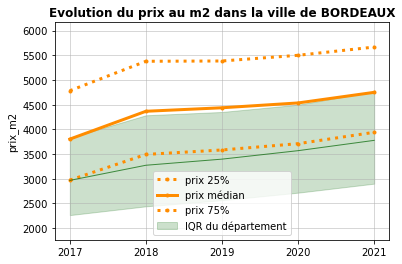

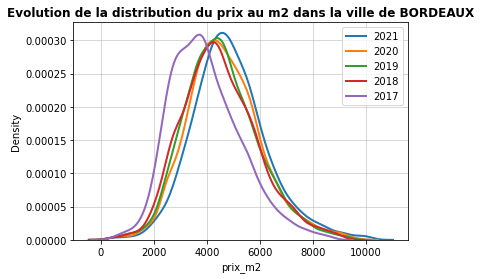

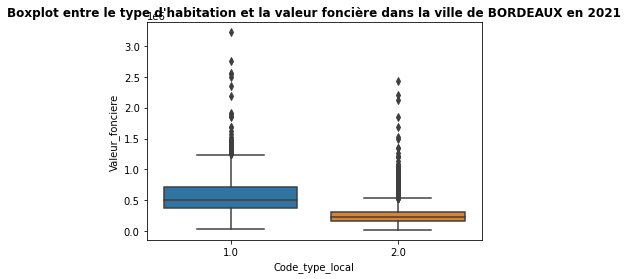

In [53]:
ville_evo("BORDEAUX",33,"prix_m2","tout",df_AllYearP)

# 5. AJOUT DE LA VARIABLE "Population_totale" PAR COMMUNE

### Sélection des variables qui nous permettrons de traiter la base de données :

In [54]:
Col_rec=["Code_departement","Code_commune","Population_totale"]

### Importation de la base de données "ensemble.xls" :

In [55]:
rec = pd.read_excel("ensemble.xls",sheet_name="Communes",usecols=Col_rec)

### Nettoyage et preprocessing de la base de données : 

In [56]:
# On ne conserve que les départements de France métropolitaine : 
rec = rec.query('Code_departement != "2A" and Code_departement != "2B"')
rec.Code_departement = rec.Code_departement.str.lstrip('0').astype(int)
rec = rec.query('Code_departement <99')

# Création d'une variable "ID_com" permettant de fusionner avec notre dataframe de valeurs foncières : 
rec['ID_com'] = rec['Code_departement'].apply(str)  + "_" + rec["Code_commune"].apply(str)
rec = rec.drop(['Code_departement', 'Code_commune'], axis=1)

### Fusion avec le dataframe de valeurs foncières :

In [57]:
result = df_AllYearP.merge(rec, on='ID_com',how="left")
df_AllYearP =result
df_AllYearP.reset_index(inplace=True)

# 6. IMPACT DU COVID

#### On cherche à savoir si le Covid a eu un impact sur les valeurs foncières. 
Pour ce faire, on créé une variable indicatrice "covid", qui prend la valeur : 
- 0 pour les années avant 2020
- 1 pour les années 2020 et 2021

In [58]:
df_AllYearP["covid"]=np.where(df_AllYearP["annee"]<2020,0,1)

On ajoute également une variable indicatrice "maison" qui prend la valeur : 
- 0 s'il s'agit d'un appartement 
- 1 s'il s'agit d'une maison

In [59]:
df_AllYearP["maison"]=np.where(df_AllYearP["Code_type_local"]==1,1,0)

## Fonction de régression linéaire multiple pour déterminer l'impact du Covid

In [60]:
def regression_covid(df):
    
    # On commence par sélectionner les variables qui entreront dans la régression : 
    X = df[["Valeur_fonciere","covid","maison","Surface_terrain",'Surface_reelle_bati',"Nombre_pieces_principales","annee","Population_totale"]]
    
    # Y est la variable dépendante. Il s'agit ici d'expliquer la valeur foncière. 
    Y = np.array(X["Valeur_fonciere"])
    
    # X est le dataframe des régresseurs :
    X = X.drop(["Valeur_fonciere"],axis=1)
    
    # Régression linéaire de Y sur X : 
    model = LinearRegression().fit(X,Y)
    
    # Récupération des valeurs estimées : 
    R_squared = str(model.score(X,Y)*100)[0:5]
    constante = str(model.intercept_)[0:5]
    coef_covid = str(list(model.coef_)[0])[0:8]
    coef_type = str(list(model.coef_)[1])[0:8]
    coef_terrain=str(list(model.coef_)[2])[0:8]
    coef_surface = str(list(model.coef_)[3])[0:8]
    coef_piece = str(list(model.coef_)[4])[0:8]
    coef_annee = str(list(model.coef_)[5])[0:8]
    coef_pop =  str(list(model.coef_)[6])[0:8]
    
    print("Equation du modèle --> Valeur fonciere =",constante," + ","covid *", coef_covid,"+","maison *",coef_type,"+","terrain *",coef_terrain,"+","surface *",coef_surface,"+ ","nb_piece *",coef_piece," + ","annee *" ,coef_annee,"+","population *",coef_pop)
    print()
    print("R squared =",R_squared,"%")
    print()
    print("Constante du modèle =",constante)
    print("Coefficient de la variable 'covid' :", coef_covid)
    print("Coefficient de la variable 'Maison' :", coef_type)
    print("Coefficient de la variable 'terrain' :", coef_terrain)
    print("Coefficient de la variable 'Surface' :", coef_surface)
    print("Coefficient de la variable 'Nombre de pièces principales' :", coef_piece)
    print("Coefficient de la variable 'Annee' :", coef_annee)
    print("Coefficient de la variable 'Population' :", coef_pop)

    return 

In [61]:
df=df_AllYearP.query('Region == "NOUVELLE_AQUITAINE"')
df=df.dropna(subset=['Population_totale'])
reg_nve_aqu=regression_covid(df) 

Equation du modèle --> Valeur fonciere = -1904  +  covid * 1694.215 + maison * 8115.790 + terrain * 8.367950 + surface * 2433.234 +  nb_piece * -5212.52  +  annee * 9430.633 + population * 0.505967

R squared = 35.45 %

Constante du modèle = -1904
Coefficient de la variable 'covid' : 1694.215
Coefficient de la variable 'Maison' : 8115.790
Coefficient de la variable 'terrain' : 8.367950
Coefficient de la variable 'Surface' : 2433.234
Coefficient de la variable 'Nombre de pièces principales' : -5212.52
Coefficient de la variable 'Annee' : 9430.633
Coefficient de la variable 'Population' : 0.505967


In [62]:
df=df_AllYearP.query('Code_departement == 33')
df=df.dropna(subset=['Population_totale'])
reg_aqu=regression_covid(df) 

Equation du modèle --> Valeur fonciere = -3552  +  covid * -7640.62 + maison * 35395.17 + terrain * 12.92370 + surface * 3080.316 +  nb_piece * -2790.87  +  annee * 17582.32 + population * 0.489608

R squared = 52.62 %

Constante du modèle = -3552
Coefficient de la variable 'covid' : -7640.62
Coefficient de la variable 'Maison' : 35395.17
Coefficient de la variable 'terrain' : 12.92370
Coefficient de la variable 'Surface' : 3080.316
Coefficient de la variable 'Nombre de pièces principales' : -2790.87
Coefficient de la variable 'Annee' : 17582.32
Coefficient de la variable 'Population' : 0.489608


In [63]:
df=df_AllYearP.query('ville == "BORDEAUX"')
df=df.dropna(subset=['Population_totale'])
reg_bdx=regression_covid(df) 

Equation du modèle --> Valeur fonciere = -4149  +  covid * -21476.9 + maison * 28200.24 + terrain * 176.3876 + surface * 4742.580 +  nb_piece * -18602.5  +  annee * 20563.75 + population * 0.0

R squared = 75.34 %

Constante du modèle = -4149
Coefficient de la variable 'covid' : -21476.9
Coefficient de la variable 'Maison' : 28200.24
Coefficient de la variable 'terrain' : 176.3876
Coefficient de la variable 'Surface' : 4742.580
Coefficient de la variable 'Nombre de pièces principales' : -18602.5
Coefficient de la variable 'Annee' : 20563.75
Coefficient de la variable 'Population' : 0.0


# 7. MODELE PREDICTIF DE LA VALEUR FONCIERE

On ajoute également une variable indicatrice "maison" qui prend la valeur :
- 0 s'il s'agit d'un appartement
- 1 s'il s'agit d'une maison
***
Remarque : on a déjà rajouté cette variable indicatrice pour regarder l'impact du covid. On la remet à cet endroit au cas où les commandes de la partie **6. Impact du Covid** n'auraient pas été exécutées.

In [64]:
df_AllYearP["maison"]=np.where(df_AllYearP["Code_type_local"]==1,1,0)

In [65]:
def reg_valeur_fonciere(dataframe,ville,year,maison,surface,surface_terrain,nombre_pieces):
    
    if maison == 1 :
        t = "une maison"
    elif maison == 0 : 
        t = "un appartement"
    
    # Extraction des données de la ville et de l'année saisies en arguments de la fonction : 
    df = dataframe.query('Commune==@ville and annee==@year')
    df = df[["Valeur_fonciere","Surface_reelle_bati","Nombre_pieces_principales","Surface_terrain","maison"]]
    
    # X est le dataframe des régresseurs :
    X = df[["Surface_reelle_bati","Surface_terrain","Nombre_pieces_principales","maison"]]
    
    # Y est la variable expliquée, en l'occurence ici la valeur foncière : 
    Y = np.array(df["Valeur_fonciere"])
    
    # Régression linéaire de Y sur X :
    model = LinearRegression().fit(X,Y)
    
    # Récupération des valeurs estimées :
    R_squared = str(model.score(X,Y)*100)[0:5]
    constante = str(model.intercept_)[0:5]
    coef_surface = str(list(model.coef_)[0])[0:8]
    coef_terain = str(list(model.coef_)[1])[0:8]
    coef_piece = str(list(model.coef_)[2])[0:8]
    coef_type = str(list(model.coef_)[3])[0:8]
    
    # Utilisation des coefficients estimés pour prédire la valeur foncière correspondant 
    # aux valeurs saisies en argument de la fonction :
    pred = round(model.predict([[surface,surface_terrain,nombre_pieces,maison]])[0])
    
    print("Equation du modèle --> Valeur fonciere =",constante," + ","surface *",coef_surface,"+ ","terrain *",coef_terain," + ","nb_piece *",coef_piece," + ","maison *",coef_type )
    print()
    print("R squared =",R_squared,"%")
    print()
    print("Coefficients obtenus correspondant à la ville de "+ ville +" pour l'année " + str(year))
    print()
    print("Constante du modèle =",constante)
    print("Coefficient de la variable 'Surface réelle' :", coef_surface)
    print("Coefficient de la variable 'Surface du terrain' :", coef_terain)
    print("Coefficient de la variable 'Nombre de pièces principales' :", coef_piece)
    print("Coefficient de la variable 'Maison' :", coef_type)
    print()
    print("Dans la ville de "+ ville + " pour l'année " + str(year) + " pour " + t)
    print("d'une surface de " + str(surface) + "m2 et d'un terrain de surface " + str(surface_terrain) +"m2")
    print("avec "+ str(nombre_pieces) + " pièce(s),")
    print("le modèle prédit une valeur foncière de", pred,"€")
    
    
    return 

In [66]:
reg_valeur_fonciere(df_AllYearP,"BORDEAUX",2021,1,60,20,2)

Equation du modèle --> Valeur fonciere = 15724  +  surface * 5325.221 +  terrain * 164.6205  +  nb_piece * -24764.0  +  maison * 44776.12

R squared = 78.82 %

Coefficients obtenus correspondant à la ville de BORDEAUX pour l'année 2021

Constante du modèle = 15724
Coefficient de la variable 'Surface réelle' : 5325.221
Coefficient de la variable 'Surface du terrain' : 164.6205
Coefficient de la variable 'Nombre de pièces principales' : -24764.0
Coefficient de la variable 'Maison' : 44776.12

Dans la ville de BORDEAUX pour l'année 2021 pour une maison
d'une surface de 60m2 et d'un terrain de surface 20m2
avec 2 pièce(s),
le modèle prédit une valeur foncière de 333778 €


In [67]:
reg_valeur_fonciere(df_AllYearP,"BORDEAUX",2021,0,45,0,2)

Equation du modèle --> Valeur fonciere = 15724  +  surface * 5325.221 +  terrain * 164.6205  +  nb_piece * -24764.0  +  maison * 44776.12

R squared = 78.82 %

Coefficients obtenus correspondant à la ville de BORDEAUX pour l'année 2021

Constante du modèle = 15724
Coefficient de la variable 'Surface réelle' : 5325.221
Coefficient de la variable 'Surface du terrain' : 164.6205
Coefficient de la variable 'Nombre de pièces principales' : -24764.0
Coefficient de la variable 'Maison' : 44776.12

Dans la ville de BORDEAUX pour l'année 2021 pour un appartement
d'une surface de 45m2 et d'un terrain de surface 0m2
avec 2 pièce(s),
le modèle prédit une valeur foncière de 205831 €
